# FTP_MachLe ML-PW-01

**Students: Noé Berdoz & Michael Strefeler.**

Assignment: `ML-PW-01.pdf`. Exercise 1 (installation) and exercise 2
(`intro-python-3.ipynb`) were done outside of this report. Exercises 3 to 6 are below.

# Exercice 3 - Data visualization

Visualisation workout on the **Iris** dataset ([wikipedia](https://en.wikipedia.org/wiki/Iris_flower_data_set)).

Goal: reproduce Figure 4 of the assignment, a pairwise scatter plot matrix. On the diagonal, the histogram of each feature. Everywhere else, the scatter plot of a pair of features, colored by species.

We follow the advice of the assignment to start with single plots and then move to a grid with `subplot`, and we will as well try the shortcut with pandas.

## Step 1: load the data

`iris.txt` is a **tab-separated** file with a header row, 150 rows and 9 columns: the 4 features,
the `Species` label, and 4 extra columns (areas and ratios) that Figure 4 does not use.


In [140]:
import matplotlib.pyplot as plt
import pandas as pd

iris = pd.read_csv("pw_resources/iris.txt", sep="\t")

FEATURES = ["Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width"]

# Same colors and markers as Figure 4 of the assignment.
STYLE = {
    "setosa": {"color": "tab:red", "marker": "o"},
    "versicolor": {"color": "tab:green", "marker": "D"},
    "virginica": {"color": "tab:blue", "marker": "*"},
}

# Confirm that the file loaded properly
print(iris.head())

# Check sample size (N) and feature dimensionality (p)
print("shape:", iris.shape)

# Check how many flowers we have per species
print("species:", iris["Species"].value_counts().to_dict())

# Make sure there are no missing values in the data
print("missing values:", int(iris.isna().sum().sum()))


   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species  Sepal.Area  \
0           5.1          3.5           1.4          0.2  setosa       17.85   
1           4.9          3.0           1.4          0.2  setosa       14.70   
2           4.7          3.2           1.3          0.2  setosa       15.04   
3           4.6          3.1           1.5          0.2  setosa       14.26   
4           5.0          3.6           1.4          0.2  setosa       18.00   

   Petal.Area  Sepal.Ratio  Petal.Ratio  
0        0.28     1.457143          7.0  
1        0.28     1.633333          7.0  
2        0.26     1.468750          6.5  
3        0.30     1.483871          7.5  
4        0.28     1.388889          7.0  
shape: (150, 9)
species: {'setosa': 50, 'versicolor': 50, 'virginica': 50}
missing values: 0


## Step 2: one plot at a time

A cell of Figure 4 is only one of two things. On the diagonal, a **histogram** of one feature: it shows how the
150 flowers are spread along that feature, with all the species mixed together.


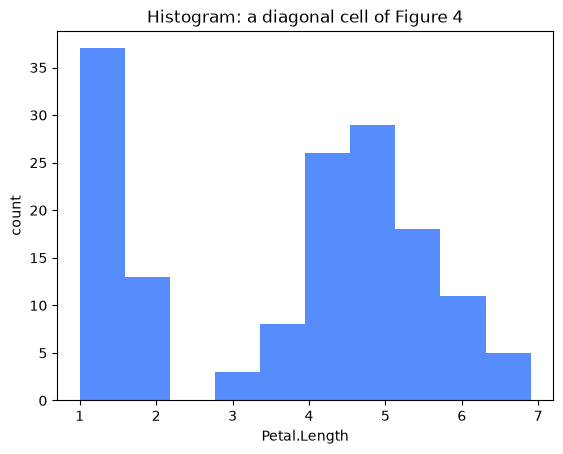

In [141]:
figure, axis = plt.subplots()
axis.hist(iris["Petal.Length"])
axis.set_xlabel("Petal.Length")
axis.set_ylabel("count")
axis.set_title("Histogram: a diagonal cell of Figure 4")
plt.show()


There are two groups: some flowers around 1 to 2 cm, then nothing, then all the others above 3 cm. But we cannot
tell which species is which, because they are all drawn in the same color.

Off the diagonal, a **scatter plot** of two features, with one color and one marker per species.


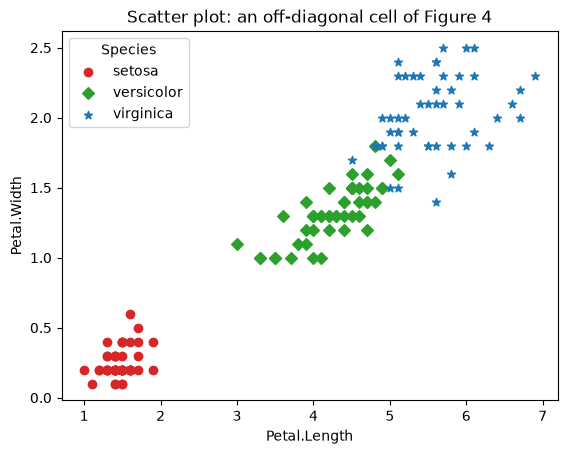

In [142]:
figure, axis = plt.subplots()

for species, style in STYLE.items():
    subset = iris[iris["Species"] == species]
    axis.scatter(
        subset["Petal.Length"],
        subset["Petal.Width"],
        color=style["color"],
        marker=style["marker"],
        label=species,
    )

axis.set_xlabel("Petal.Length")
axis.set_ylabel("Petal.Width")
axis.set_title("Scatter plot: an off-diagonal cell of Figure 4")
axis.legend(title="Species")
plt.show()


Now we see which group is which: the small flowers at the bottom left are *setosa*. *Versicolor* and *virginica*
are two clouds next to each other, and they touch.

## Step 3: the grid with `subplots`

Figure 4 is these two plots repeated 16 times. In a 4x4 grid, when the row and the column are the same feature we
draw the histogram, otherwise the scatter plot. We keep the tick labels on the outside only.


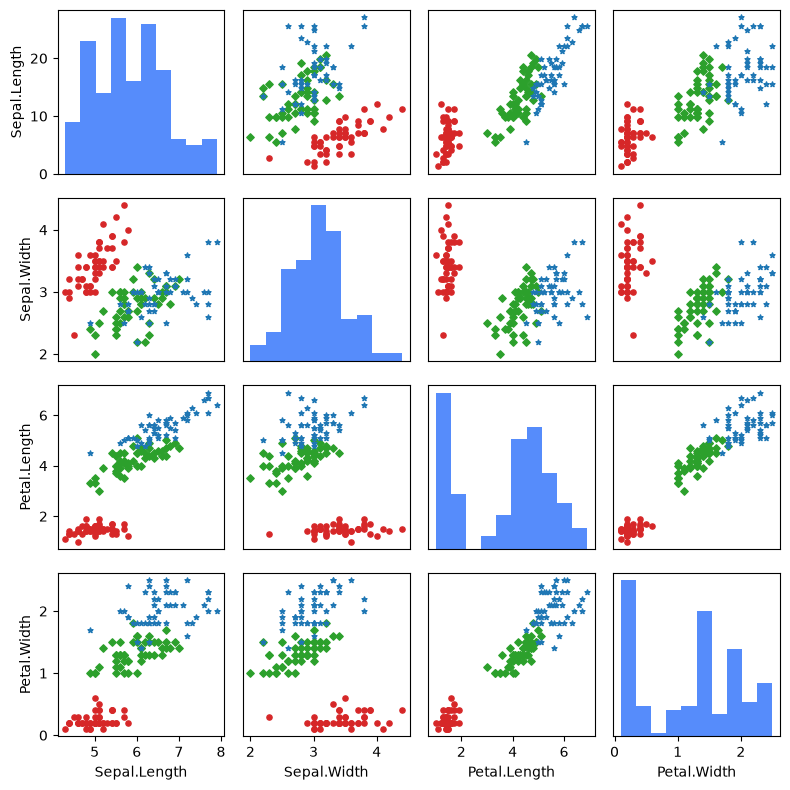

In [143]:
n = len(FEATURES)

fig, axes = plt.subplots(n, n, figsize=(8, 8))

for row, y_feat in enumerate(FEATURES):
    for col, x_feat in enumerate(FEATURES):
        ax = axes[row, col]

        # Diagonal: histogram of the single feature
        if row == col:
            ax.hist(iris[x_feat], bins=10)
        # Off-diagonal: scatter plot colored by species
        else:
            for species, style in STYLE.items():
                subset = iris[iris["Species"] == species]
                ax.scatter(
                    subset[x_feat],
                    subset[y_feat],
                    s=14,
                    color=style["color"],
                    marker=style["marker"],
                )

        # Y-axis: label on the left border, remove inner ticks
        if col == 0:
            ax.set_ylabel(y_feat)
        else:
            ax.tick_params(left=False, labelleft=False)

        # X-axis: label on the bottom border, remove inner ticks
        if row == n - 1:
            ax.set_xlabel(x_feat)
        else:
            ax.tick_params(bottom=False, labelbottom=False)

plt.tight_layout()
plt.show()

## Step 4: the pandas shortcut alternative

The same figure in one call, with `pandas.plotting.scatter_matrix`. pandas builds the grid, the histograms and
the labels for us. We only give it one color per flower: it draws all the points in a single call, so it cannot
use one marker per species.


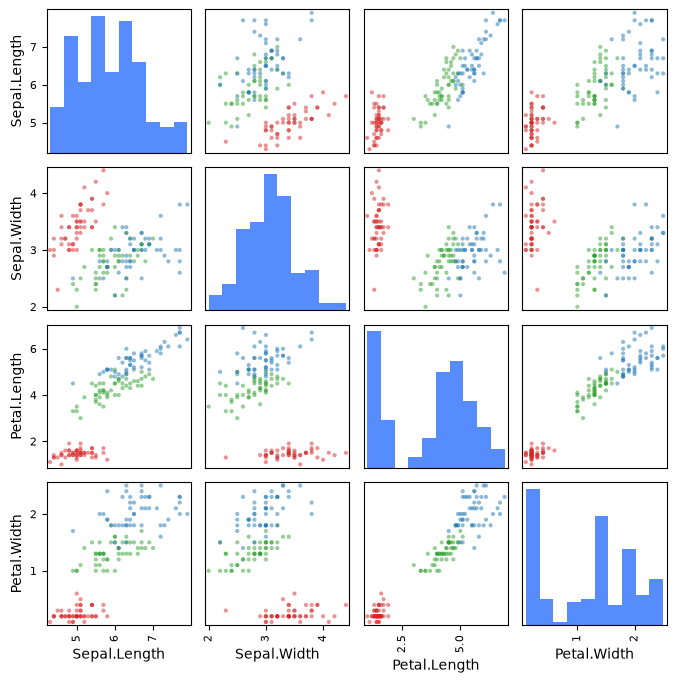

In [144]:
# Map each flower's species to its color from STYLE
colors = iris["Species"].map({s: STYLE[s]["color"] for s in STYLE})

# Generate the 4x4 matrix using the pandas built-in shortcut
pd.plotting.scatter_matrix(iris[FEATURES], figsize=(8, 8), color=colors)
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()


## Step 5 (Bonus) : the number of bins changes the picture

If we change the number of bins, our histogram of step 2 (and the one of Figure 4) will not have the same shape, even though the data is the same. Here is a comparaison of the default 10 bins and one with 12 bins to compare outputs.


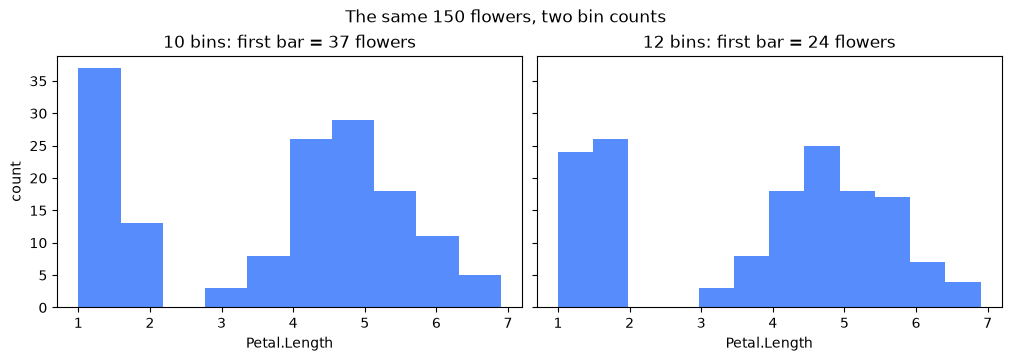

In [145]:
figure, axes_row = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True, layout="constrained")

for axis, bin_count in zip(axes_row, [10, 12]):
    # histogram returns (counts, bin edges, bars), we keep the counts for the title.
    counts = axis.hist(iris["Petal.Length"], bins=bin_count)[0]
    axis.set_title(f"{bin_count} bins: first bar = {int(counts[0])} flowers")
    axis.set_xlabel("Petal.Length")

axes_row[0].set_ylabel("count")
figure.suptitle("The same 150 flowers, two bin counts")
plt.show()


Petal length is measured in steps of 0.1 cm, and inside the setosa group the values pile up on 1.4 cm (13
flowers) and on 1.5 cm (13 flowers). With 10 bins the first bar covers 1.0 to 1.59 cm, so the two piles stay
together: 37 against 13, one tall bar then a short one, like Figure 4. With 12 bins the first bar stops at
1.49 cm, right between the two piles, so they are separated: 24 against 26, and the second bar becomes the
taller one.

So the shape of a histogram depends on the bins as much as on the data, and it is worth trying a few values
before reading a conclusion in it. Here what does not move is the important part: two groups of flowers, and an
empty space between 2 and 3 cm.


## Answers

**What can you say regarding class separation?**

It depends on the feature. With the sepal features the three colors are mixed in the same cloud, so they are not
enough to tell the species apart. With the petal features we see three groups, so these two features carry most
of the useful information.

**One class seems easier to distinguish from the others, which one?**

*Setosa*, in red. On every plot that uses a petal feature it is alone in a corner, far from the others. On the
petal length axis it stays around 1 to 2 cm while the two others are above 3 cm, and no flower sits in between.
A single vertical line, around 2.5 cm of petal length, puts all the setosa on one side and nothing else with
them.

**How would you separate the other two?**

*Versicolor* (green) and *virginica* (blue) are side by side and they touch, so no line separates them
perfectly: a few green points are inside the blue group. The best pair of features is again petal length and
petal width, where the two groups are the most stretched apart. In that plane a straight line, tilted so that it
uses both features at the same time, keeps almost all the flowers on the right side. This is what a linear
classifier (logistic regression, linear SVM) learns. The few flowers that stay on the wrong side would need a
curved boundary (k-nearest neighbours, SVM with a kernel, decision tree), and then we should check on a test set
that we did not simply learn these particular flowers.


# Exercice 4 - Find your own examples of Machine Learning Tasks

### Tableau 1-1. Quelques exemples de machine learning proposés par Mitchell

| Use Case                  | Checkers learning | Handwriting recognition | Robot driving learning | Housing market prediction | Spam email filtering |
|:--------------------------| :--- | :--- | :--- |:--------------------------| :--- |
| **Tasks T**               | Playing checkers | Recognizing and classifying handwritten words within images | Driving on public four-lane highways using vision sensors | Predicting the market sale price of a house from its features | Classifying an incoming email message into one of two classes |
| **Performance measure P** | Percent of games won against opponents | Percent of words correctly classified | Average distance traveled before an error (as judged by human overseer) | Root Mean Squared Error (RMSE) between predicted and actual prices | Percentage of emails correctly labeled |
| **Training experience E** | Playing practice games against itself | A database of handwritten words with given classifications | A sequence of images and steering commands recorded while observing a human driver | A historical dataset of past home sales containing house attributes and sale prices | A dataset of emails with ground truth labels |


# Exercice 5 - Review questions

## 1) Supervised vs. unsupervised systems

Of the following examples, which one would you address using a supervised or an unsupervised learning algorithm?
Give some explanations for your answers.

| | Case | Supervised / Unsupervised | Why |
|---|---|---|---|
| a) | Given email labeled as spam/not spam, learn a spam filter. | Supervised | The model is trained with a dataset containing the ground truth |
| b) | Given a set of news articles found on the web, group them into sets of related articles. | Unsupervised | The model is not trained with pre-existing labels |
| c) | Given a database of customer data, automatically discover market segments and group customers into different market segments. | Unsupervised | The model identifies hidden patterns on its own without pre-established definitions, it sounds like a typical clustering task |
| d) | Given a dataset of patients diagnosed as either having glaucoma or not, learn to classify new patients as having glaucoma or not. | Supervised | The dataset contains measurments with a clinical diagnosis label (ground truth) |

## 2) Classification vs. regression systems

> Can we transform a regression problem into a classification problem? What would be the benefits of doing so?

Yes, it is possible to transform a regression problem into a classification problem by grouping continuous values into ranges or categories. For example, instead of predicting an exact stock price, we can predict whether it goes up or down (2 classes), or predict age brackets (e.g. <20, 20–30, >30) instead of the exact age.

The main benefit is that it generally makes the system simpler to tune.

## 3) Other questions

**a) Why is it important that a test set is independent from the training set in a machine learning system?**

So we can ensure that the model isn't suffering from overfitting.

**b) What is the meaning of the hat in the equation $\hat{y} = h(x)$?**

It's the output variable, it denotes the predicted (or estimated) value of the target, as opposed to the true ground truth $y$.

**c) What is the difference between machine learning and statistics?**

Statistics wants to explain the data generating process _"Why did this happen?"_.
Machine learning wants to predict future outcomes accurately _"What will happen next?"_

**d) Is a detection system a regression or a classification system? Give an example.**

A detection system is a classification system with two classes. its output is a label, not a continuous value so it's not a regression.

As exemple, we can take the face check at airport gate: the system compares the traveller's face to the passport picture and outputs a label "match" or a label "no match".


# Exercice 6 - Reading assignments

References (pdfs on Moodle):

- Murphy, *Machine Learning: a Probabilistic Perspective*, chapter 1.
- Biernat & Lutz, *Data Science: fondamentaux et études de cas*, chapter 1.

## Summary of the two chapters

The two chapters answer the same question from opposite ends. Murphy defines machine learning as a set of methods
that detect patterns in data and use them to predict or to decide under uncertainty, and reduces the field to one
task: estimating a probability distribution, so a model returns a confidence and not only an answer. Biernat &
Lutz start earlier, before any algorithm: first you need data, then you need to know what you want from it. They
spend their chapter on the data itself, quantitative or qualitative, structured or not. They warn that by default
there is *no* link in it, publication bias and false correlations making us see patterns that are not there.
Both end in the same object: a matrix, one row per observation, one column per feature. What sorts the problems is
what sits next to it.

## Taxonomy of machine learning problems

Murphy sorts problems by what the data looks like, Biernat & Lutz sort algorithms on two axes (supervised or not,
regression or classification). The question asks for problems, so we keep Murphy's tree and read their axes across
it.

- **Supervised learning**: input/output pairs, the output fixed in advance by an expert or by history. We learn a
  prediction function and judge it on inputs it has never seen.
  - **Classification**: the output is one label out of a finite set. *Example*: spam versus ham. Binary (is this
    tumour dangerous, in Biernat & Lutz), multiclass (the three iris species of exercise 3), or multi-label when
    the labels are not exclusive. Detection is the same classifier run over every patch of a signal, like Murphy's
    face detection, which is why we called it a classification system in exercise 5.
  - **Regression**: the output is a real number. *Example*: the price of a house from its surface.
  - **Ordinal regression**: labels that are finite but ordered, between the two. *Example*: grades A–F.
- **Unsupervised learning**: only the inputs are given, so there is no target and no obvious error metric.
  Murphy unifies the branch as estimating the density of the data.
  - **Clustering**: group the observations that look alike, the number of groups being part of the problem.
    *Example*: customer segmentation.
  - **Dimensionality reduction**: project onto fewer dimensions that keep the essence. *Example*: PCA on face
    images, giving Murphy's eigenfaces.
  - **Graph structure discovery**: find which variables directly depend on which. *Example*: a protein network.
  - **Matrix completion**: fill the missing entries of a partly observed matrix. *Example*: the Netflix ratings,
    of which 1% are known.
  - **Association rules**: which items turn up together. *Example*: bread and butter in the same basket.
  - **Anomaly detection**: flag what does not look like the rest. *Example*: card fraud. Named by Biernat &
    Lutz, developed by neither chapter.
- **Semi-supervised learning**: a few labelled rows among many unlabelled ones. Biernat & Lutz name it and move
  on, Murphy does not mention it. *Example*: a handful of labelled documents in a large corpus.
- **Reinforcement learning**: no dataset at all, an agent acts and receives an occasional reward. Out of scope in
  chapters. *Example*: an agent learning to play Flappy Bird.

Two distinctions cut across the tree. The regression/classification axis of Biernat & Lutz only applies to the
supervised branch: an unsupervised algorithm has no output to type, which is why that column stays empty for
clustering and PCA in their table. Murphy's parametric versus non-parametric split describes the model rather
than the problem. And no branch is safe on its own: Murphy warns about overfitting and the curse of dimensionality,
Biernat & Lutz about finding a pattern that was never in the data, and the no free lunch theorem says that no
model wins everywhere.